**Q2.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

 1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.

In [2]:
# load in data
df = pd.read_csv("cars_hw.csv")
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unnamed: 0         976 non-null    int64
 1   Make               976 non-null    str  
 2   Make_Year          976 non-null    int64
 3   Color              976 non-null    str  
 4   Body_Type          976 non-null    str  
 5   Mileage_Run        976 non-null    int64
 6   No_of_Owners       976 non-null    str  
 7   Seating_Capacity   976 non-null    int64
 8   Fuel_Type          976 non-null    str  
 9   Transmission       976 non-null    str  
 10  Transmission_Type  976 non-null    str  
 11  Price              976 non-null    int64
dtypes: int64(5), str(7)
memory usage: 91.6 KB


- Want to take the log of price since heavy right skew after looking at teh data wrangler
- maybe log milaege too
- drop the unnames col casue its just an index

In [4]:
#drop the column of extra index
df = df.drop(columns=["Unnamed: 0"])
#make new columns of the logs of price and milege
df['log_Price'] = np.log(df['Price'])
df['log_Mileage_Run'] = np.log(df['Mileage_Run'])

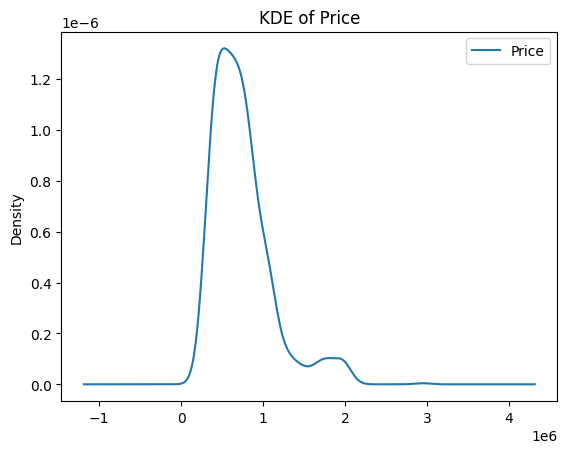

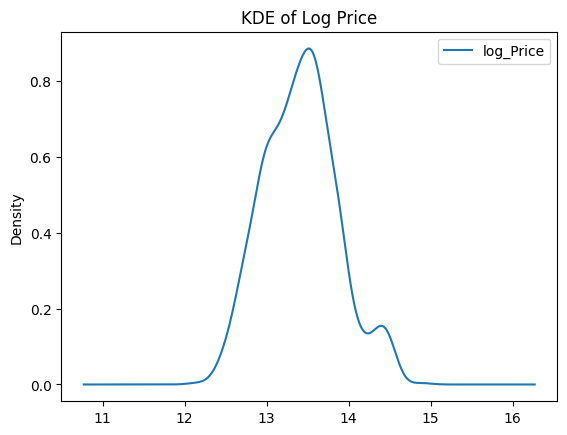

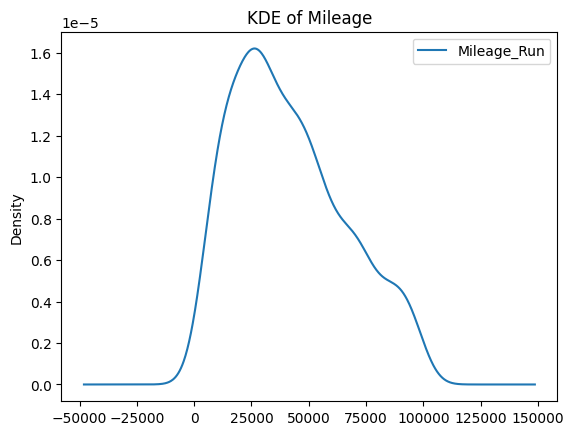

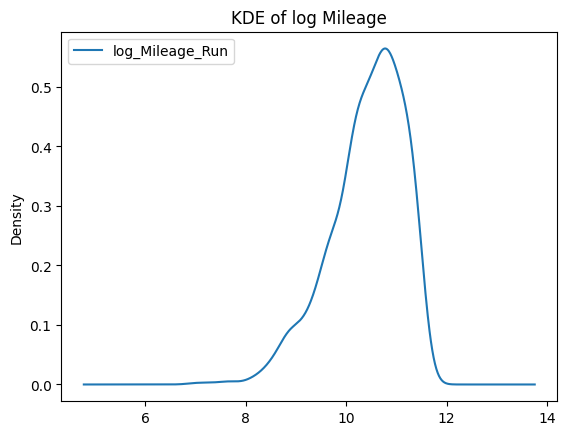

In [5]:
# KDE for price
df['Price'].plot.kde(legend=True)
plt.title('KDE of Price')
plt.show()


# KDE for log price
df['log_Price'].plot.kde(legend=True)
plt.title('KDE of Log Price')
plt.show()

# KDE for mileage
df['Mileage_Run'].plot.kde(legend=True)
plt.title('KDE of Mileage')
plt.show()

# KDE for log mileage
df['log_Mileage_Run'].plot.kde(legend=True)
plt.title('KDE of log Mileage')
plt.show()

the kde before log shows that the cars are mostly the same price but then tehres a couple outlier expensive ones that are pulling out the tail and making it have a right skew. so going to go with the logged version of price that has more of a noraml shape. the same thing could be said for mialege thought no as strong of a skew. better safe thought and use the log on it aswell.

In [6]:
categorical_cols = ['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type']
cat_dummies = pd.get_dummies(df[categorical_cols], drop_first=True, prefix=['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type'])
print(cat_dummies.head())

   Make_Datsun  Make_Ford  Make_Honda  Make_Hyundai  Make_Jeep  Make_Kia  \
0        False      False       False         False      False     False   
1        False      False       False          True      False     False   
2        False      False        True         False      False     False   
3        False      False       False         False      False     False   
4        False      False       False          True      False     False   

   Make_MG Motors  Make_Mahindra  Make_Maruti Suzuki  Make_Nissan  ...  \
0           False          False               False        False  ...   
1           False          False               False        False  ...   
2           False          False               False        False  ...   
3           False          False               False        False  ...   
4           False          False               False        False  ...   

   Body_Type_suv  No_of_Owners_2nd  No_of_Owners_3rd  Fuel_Type_petrol  \
0          False        

2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?

In [7]:
print(df['log_Price'].describe())

count    976.000000
mean      13.411033
std        0.450276
min       12.144197
25%       13.072647
50%       13.409795
75%       13.691080
max       14.894260
Name: log_Price, dtype: float64


In [8]:
brand_price = df.groupby('Make')['log_Price']

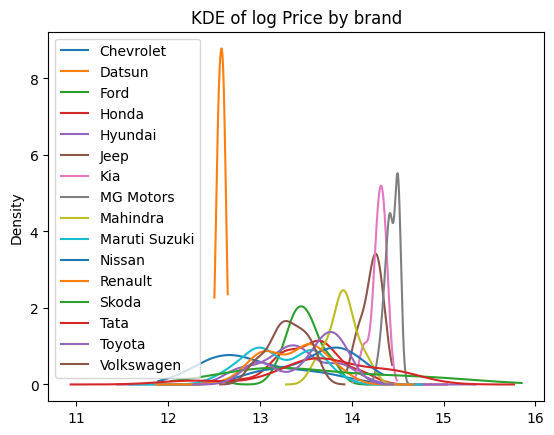

In [9]:
brand_price.plot.kde(legend=True)
plt.title('KDE of log Price by brand')
plt.show()

In [10]:
print(brand_price.describe().sort_values('mean', ascending=False))

               count       mean       std        min        25%        50%  \
Make                                                                         
MG Motors       35.0  14.439052  0.066263  14.278615  14.395744  14.429615   
Kia              8.0  14.292177  0.076877  14.129591  14.272242  14.303105   
Jeep             4.0  14.216591  0.105084  14.070153  14.183270  14.240265   
Mahindra        18.0  13.898953  0.159906  13.587354  13.851808  13.905680   
Tata            23.0  13.713405  0.615090  12.144197  13.566383  13.675098   
Nissan           4.0  13.641194  0.392610  13.071070  13.537775  13.788723   
Skoda            5.0  13.640864  0.827046  12.985398  13.051941  13.195614   
Honda           73.0  13.536318  0.336972  12.663497  13.272506  13.573439   
Toyota          50.0  13.535507  0.360112  12.815838  13.171414  13.703461   
Ford            52.0  13.468280  0.210895  12.577636  13.361380  13.469493   
Hyundai        305.0  13.368511  0.398781  12.421184  13.091904 

Mg moters, kia, and keep all have high denisotyss on th ehigher end of the price scale. they each have a visiable adn defined curve while most averages have a wide range prices. however one car brand that stand out if Datsun which only has a count of 3 and a very small std which means that almost all the entrys are very close in price which gives it that skinny tall line on teh kde.

 3. Split the data into an 80% training set and a 20% testing set.

In [11]:
#make list of all category cols
categorys = ['Make', 'Color', 'Body_Type', 'Fuel_Type', 'Transmission_Type', 'Make_Year']
#make dummies of all the categoricial features
cat_dummies = pd.get_dummies(df[categorys], drop_first=True)
print(cat_dummies.columns.tolist())

['Make_Year', 'Make_Datsun', 'Make_Ford', 'Make_Honda', 'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG Motors', 'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan', 'Make_Renault', 'Make_Skoda', 'Make_Tata', 'Make_Toyota', 'Make_Volkswagen', 'Color_black', 'Color_blue', 'Color_bronze', 'Color_brown', 'Color_golden', 'Color_green', 'Color_grey', 'Color_maroon', 'Color_orange', 'Color_purple', 'Color_red', 'Color_silver', 'Color_white', 'Color_yellow', 'Body_Type_hatchback', 'Body_Type_muv', 'Body_Type_sedan', 'Body_Type_suv', 'Fuel_Type_petrol', 'Fuel_Type_petrol+cng', 'Transmission_Type_Manual']


In [12]:
# make list of just the numerical features
numeric_cols = ['log_Mileage_Run', 'Seating_Capacity']

# Define X and y
X = df[numeric_cols] + cat_dummies
#target is log price
y = df['log_Price']

# splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?

In [13]:
#first model - numeric 
X_num = df[numeric_cols]
#split
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split( X_num, y, test_size=0.2, random_state=42)
#fit in trinaing 
model_num = LinearRegression()
model_num.fit(X_train_num, y_train_num)
#predict
y_pred_num = model_num.predict(X_test_num)
#evaluate
r2_num_train = r2_score(y_train_num, model_num.predict(X_train_num))
r2_num_test = r2_score(y_test_num, y_pred_num)
rmse_num = np.sqrt(mean_squared_error(y_test_num, y_pred_num))
print(f"Training R²:{r2_num_train}")
print(f"Test R²:{r2_num_test}")
print(f"Test RMSE: {rmse_num}")


Training R²:0.0350281564920617
Test R²:0.06529393296499209
Test RMSE: 0.4221985859480194


In [14]:
#second model - categorical  
X_cat = cat_dummies
#split
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X_cat, y, test_size=0.2, random_state=42)
#fit in trinaing 
model_cat = LinearRegression()
model_cat.fit(X_train_cat, y_train_cat)
#predict
y_pred_cat = model_cat.predict(X_test_cat)
#evaluate
r2_cat_train = r2_score(y_train_cat, model_cat.predict(X_train_cat))
r2_cat_test = r2_score(y_test_cat, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test_cat, y_pred_cat))
print(f"Training R²:{r2_cat_train}")
print(f"Test R²:{r2_cat_test}")
print(f"Test RMSE: {rmse_cat}")


Training R²:0.8147777830827743
Test R²:0.7887865575054124
Test RMSE: 0.20069660274405796


In [15]:
#third model - combined  
X_combined = pd.concat([df[numeric_cols], cat_dummies], axis=1)
#split
X_train_comb, X_test_comb, y_train_comb, y_test_comb = train_test_split(X_combined, y, test_size=0.2, random_state=42)
#fit in trinaing 
model_comb = LinearRegression()
model_comb.fit(X_train_comb, y_train_comb)
#predict
y_pred_comb = model_comb.predict(X_test_comb)
#evaluate
r2_comb_train = r2_score(y_train_comb, model_comb.predict(X_train_comb))
r2_comb_test = r2_score(y_test_comb, y_pred_comb)
rmse_comb = np.sqrt(mean_squared_error(y_test_comb, y_pred_comb))
print(f"Training R²:{r2_cat_train}")
print(f"Test R²:{r2_cat_test}")
print(f"Test RMSE: {rmse_cat}")


Training R²:0.8147777830827743
Test R²:0.7887865575054124
Test RMSE: 0.20069660274405796


In [16]:
# compare all 3 models 
print("Model 1 Test R²:", r2_num_test)
print("Model 2 Test R²:", r2_cat_test)
print("Model 3 Test R²:", r2_comb_test)


print("Model 1 Test RMSE:", rmse_num)
print("Model 2 Test RMSE:", rmse_cat)
print("Model 3 Test RMSE:", rmse_comb)

Model 1 Test R²: 0.06529393296499209
Model 2 Test R²: 0.7887865575054124
Model 3 Test R²: 0.7990187936730093
Model 1 Test RMSE: 0.4221985859480194
Model 2 Test RMSE: 0.20069660274405796
Model 3 Test RMSE: 0.19577488065745197


- numeric was the worst one becuase it had the lowest r^2 value at .065 which makes sence cause mileage and seating capacity dont have much correlation adn say alot about a cars price type alone.
- cateorigcal was a way better with r^2 .789 which makes send becuase it had information like the year and the brand which are more titly revealing about what the price represents.
- the combined of numerica and cateogrical has the highedst r^2 and this msakes snese beucase it has the most infromation. the model can make a more accurate picture when it has the most infromaiton it can build off of. while the categorical cols have alot more say the numeric cals also have some importance.
- these also align with the rmse values which show the at the combine has teh lowest which is good cause that reveals that the error difrancees it smaller. 

5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?

In [17]:
# PolynomialFeatures makes new columns from the num cols and increases the polynomial to see which
# best degree makes the model fit the best
#cant do it on categorical though

#make x the numeircla cols only
X = df[numeric_cols]
#still keep y as the log price target variable
y = df['log_Price']

#run this look for teh degrere values of 1 to 5
degrees = range(1, 6)
#list that saves results
results_poly = []

#loop thgouht each degree value adn save outputs
for deg in degrees:
    # create polynomial features up to the 5th degree
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    # include_bias=False bc linreg adds its own intercept
    
    # transform the num features
    X_poly = poly.fit_transform(X)
    
    # split testing adn training
    X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y, test_size=0.2, random_state=42)
    
    # fit to training data
    model_poly = LinearRegression()
    model_poly.fit(X_train_p, y_train_p)
    
    # evaluate r^2 and rmse for testing and training
    r2_train = r2_score(y_train_p, model_poly.predict(X_train_p))
    r2_test  = r2_score(y_test_p,  model_poly.predict(X_test_p))
    rmse_test= np.sqrt(mean_squared_error(y_test_p, model_poly.predict(X_test_p)))
    n_features = X_poly.shape[1]
    
    #add all these results to the results list
    results_poly.append({
        'Degree': deg,
        'Num Features': n_features,
        'Train R²':round(r2_train, 4),
        'Test R²': round(r2_test, 4),
        'Test RMSE':round(rmse_test, 4)
    })

#save the results of the loop to a data frame so can read eaiser
poly_df = pd.DataFrame(results_poly)
print(poly_df)

   Degree  Num Features  Train R²  Test R²  Test RMSE
0       1             2    0.0350   0.0653     0.4222
1       2             5    0.0695   0.0893     0.4167
2       3             9    0.0771   0.0601     0.4234
3       4            14    0.0849   0.0565     0.4242
4       5            20    0.0860   0.0544     0.4247


when the degree increases the r^2 rises for training data consitenly but on the testing data it only rises to degree 2 then begins to decrease. while the rmse does start to drop on the testing data, it also rises after the 2degree. this shows that one the higher degrree the polynomial is overfitting. so the best polynomial for this would be to 2nd degree. for the numeric only model from part 4 this model was better breuace the part 4 one only used 1 degree.

the best polynomial degree for the numeric-only features is degree 2 bc thats where test R^2 peaks at 0.0893 and RMSE dips to 0.417. after that, even tho training R^2 keeps going up, test R^2 starts falling. this is classic overfitting pattern. the model is learning the training data too specific instead of the actual signal. so the degree 5 would technically have a perfectish training fit but would be terrible on any new data. even at its best though, the numeric modelis way worse than the combined model from part 4 so this confirms that the categorical variables like brand and year are carrying almost all the predictive power here, not the numeric ones.


6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

/tmp/ipykernel_31009/3192038526.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


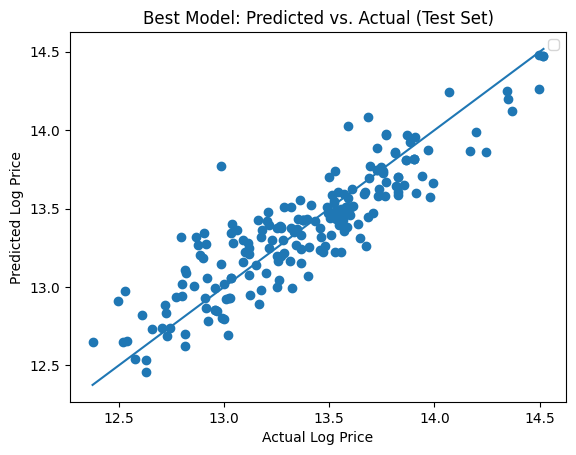

In [18]:
# im gonna use the combined model from part 4 that had the best r^2 and rmse
#y_test_comb
#y_pred_comb

plt.scatter(y_test_comb, y_pred_comb)
plt.plot([y_test_comb.min(), y_test_comb.max()], [y_test_comb.min(), y_test_comb.max()])
plt.xlabel('Actual Log Price')
plt.ylabel('Predicted Log Price')
plt.title('Best Model: Predicted vs. Actual (Test Set)')
plt.legend()
plt.show()

the predicted vs actual plot shows the points clustering pretty closely around the diagonal, which is a good sign that the model is making reasonable predictions. theres a little more spread at the higher end of prices which makes sense since expensive cars are rarer and harder to predict accurately.

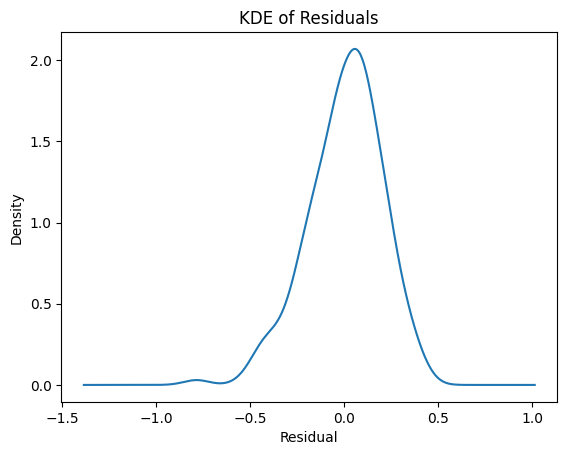

Mean residual:0.0034207179314621086
Std of residuals:0.19574499376809854


In [19]:
#calculateed the residuals
residuals = y_test_comb.values - y_pred_comb

pd.Series(residuals).plot.kde()
plt.xlabel('Residual')
plt.title('KDE of Residuals')
plt.show()

print(f"Mean residual:{residuals.mean()}")
print(f"Std of residuals:{residuals.std()}")

the residual KDE looks pretty bell-shaped and centered really close to zero which means the model isnt systematically over or under predicting. the std of 0.196 matches the RMSE which makes sense. theres a little right tail meaning the model occasionally underpredicts price for some listings, but overall the distribution is pretty good. a strenght is that the combined model uses the most available information and the log transformation made both price and mileage better behaved for regression. the residuals are clean and centered at zero. while a weekness is the polynomial expansion of the numeric variables barely helped at all cause mileage and seating capacity just don't explain much price variation once you already have brand and year. also the dataset is also pretty small at and theres still some missing info like car condition and other factors that could help get even better prediction